# Chapter 1 - Artificial Intelligence

## Unsupervised Learning

In [5]:
import numpy as np
import pandas as pd
from pylab import plt, mpl

#plt.style.use('seaborn')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(precision=4, suppress=True)

In [6]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [7]:
# A sample data set is created with clustered features data.
x, y = make_blobs(n_samples=100, centers=4, random_state=500, cluster_std=1.25)

In [8]:
# A KMeans model pbject is instantiated, fixing the number of clusters.
model = KMeans(n_clusters=4, random_state=0)

In [9]:
# The model is fitted to the features data
model.fit(x)

c:\Users\roly_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, random_state=0)

In [10]:
# The predictions are generated given the fitted model.
y_ = model.predict(x)

# The predictions are numbers from 0 to 3, each representing one cluster
y_

array([1, 1, 0, 3, 0, 0, 1, 3, 0, 3, 3, 1, 3, 2, 2, 1, 3, 2, 3, 2, 2, 1,
       0, 3, 0, 0, 2, 2, 0, 1, 3, 0, 0, 2, 0, 1, 0, 1, 3, 3, 3, 0, 2, 2,
       1, 0, 3, 2, 3, 2, 1, 2, 0, 2, 0, 1, 0, 3, 2, 1, 0, 2, 1, 3, 1, 2,
       0, 0, 0, 3, 1, 0, 3, 2, 3, 1, 3, 2, 3, 3, 0, 1, 0, 1, 3, 3, 1, 3,
       2, 2, 2, 1, 1, 1, 1, 2, 1, 0, 2, 2], dtype=int32)

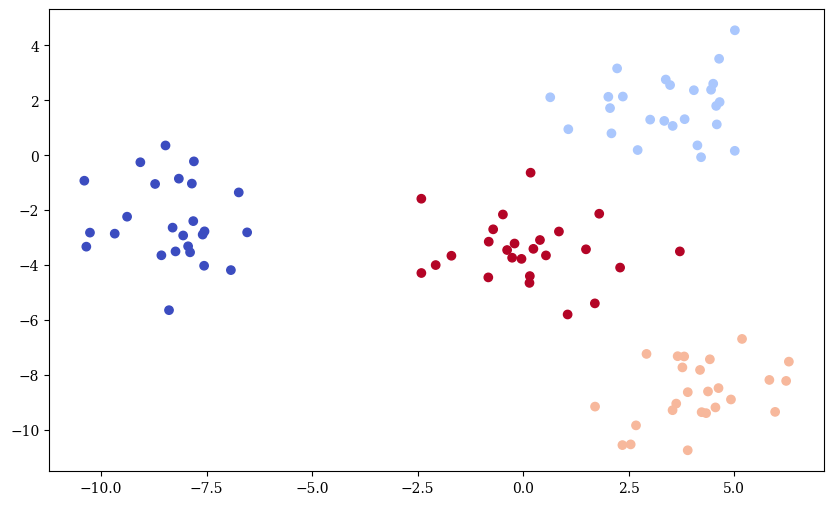

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(x[:,0], x[:,1], c=y_, cmap='coolwarm')

## Reinforcement learning

The following example is based on a coin tossing game that is played with a coin that lands 80% of the time on heads and 20% of the time on tails.

The baseline algorithm, which bets randomly and equally distributes on heads and tails, achieves a total reward of round 50, on average, per epoch of 100 bets.

In [12]:
# The state space (1 = heads, 0 = tails)
ssp = [1,1,1,1,0]

In [13]:
# The action space (1 = bet on heads, 0 = bet on tails)
asp = [1,0]

In [14]:
def epoch():
    tr = 0
    for _ in range(100):
        # An action is randomly chosen from the action space
        a = np.random.choice(asp)
        # A state is randomly chosen from the state space
        s = np.random.choice(ssp)
        if a == s:
            # The total reward tr is increased by one of the bet is correct.
            tr += 1
    return tr

In [15]:
# The game is played for a number of epochs, each epoch is 100 bets.
rl = np.array([epoch() for _ in range(15)])
print (rl)

[51 46 49 55 51 56 56 48 50 46 46 41 41 45 55]


In [16]:
# The average total reward of the epochs played is calculated
print (rl.mean())

49.06666666666667


The average total reward increase reflects the improvement of the learning algorithm as compared to the uniformed baseline algorithm:

In [17]:
ssp = [1,1,1,1,0]

def epoch():
    tr = 0
    asp = [0,1]
    for _ in range(100):
        a = np.random.choice(asp)
        s = np.random.choice(ssp)
        if a == s:
            tr += 1
        asp.append(s)  # Adds the observed state to the action space
    return tr

rl = np.array([epoch() for _ in range(15)])
print (rl)
print (rl.mean())

[65 59 69 77 58 64 69 55 58 50 79 65 70 65 69]
64.8


## Neural Networks

### OLS Regression
Ordinary least-squares

In [18]:
def f (x):
    return 2 * x ** 2 - x ** 3 / 3

In [19]:
# The input values
x = np.linspace(-2, 4, 25)
print (x)

[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.  ]


In [20]:
y = f(x)
print (y)

[10.6667  7.9115  5.625   3.776   2.3333  1.2656  0.5417  0.1302  0.
  0.1198  0.4583  0.9844  1.6667  2.474   3.375   4.3385  5.3333  6.3281
  7.2917  8.1927  9.      9.6823 10.2083 10.5469 10.6667]


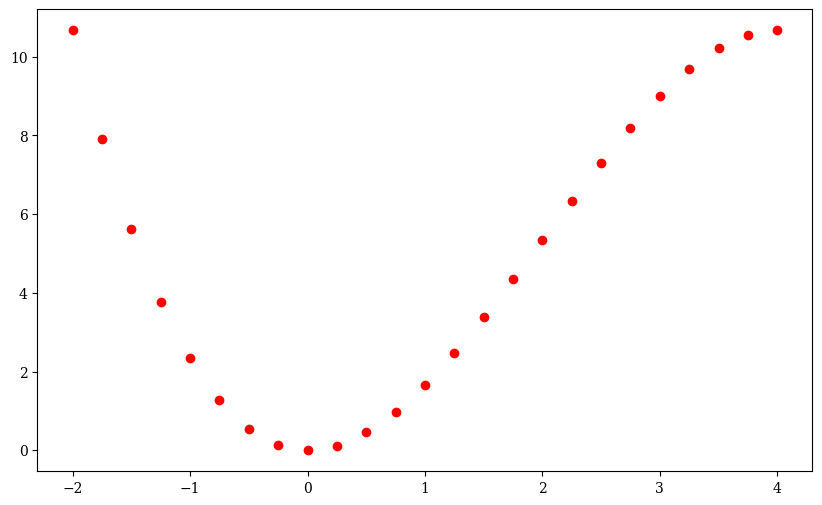

In [21]:
plt.figure(figsize=(10,6))
plt.plot(x,y, 'ro')

The following python code calculates the optimal parameter values, linearly estimates (approximates) the output values, and plots the linear regression line alongside the sample data.

In [22]:
# Calculation of optimal Beta
beta = np.cov(x, y, ddof=0)[0,1] / np.var(x)
print (beta)

1.0541666666666667


In [23]:
# Calculation of optimal alpha
alpha = y.mean() - beta * x.mean()
print (alpha)

3.8625000000000003


In [24]:
# Calculation of estimated values (y = a + Bx)
y_ = alpha + beta * x

In [25]:
# Calculation of the MSE given the approximation
MSE = ((y - y_) ** 2).mean()
print (MSE)

10.721953125


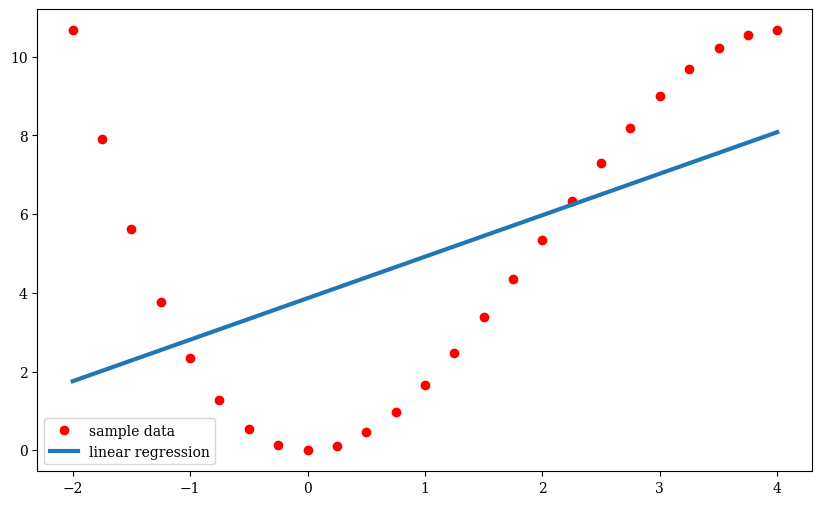

In [26]:
plt.figure(figsize=(10,6))
plt.plot(x, y, 'ro', label='sample data')
plt.plot(x, y_, lw=3.0, label='linear regression')
plt.legend()

deg=1 | MSE=10.72195
deg=2 | MSE=2.31258
deg=3 | MSE=0.00000
[-0.3333  2.      0.     -0.    ]


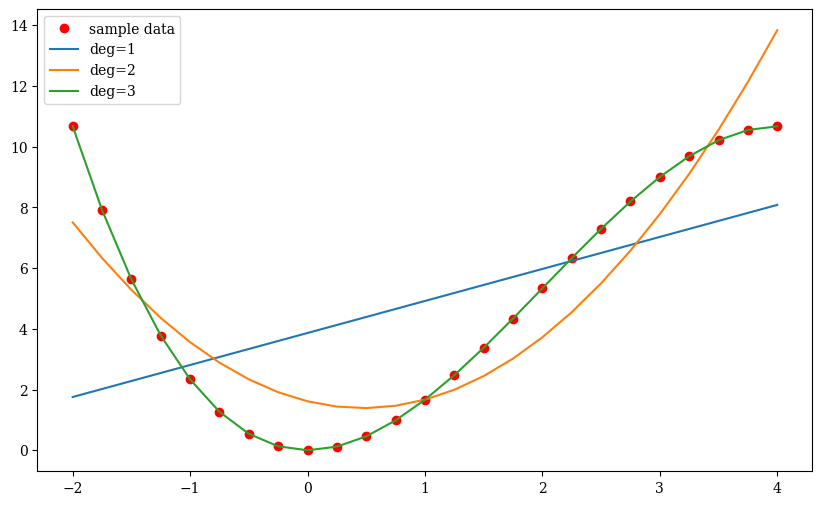

In [27]:
plt.figure(figsize=(10,6))
plt.plot(x, y, 'ro', label='sample data')
for deg in [1, 2, 3]:
    reg = np.polyfit(x, y, deg=deg)
    y_ = np.polyval(reg, x)
    MSE = ((y - y_) ** 2).mean()
    print(f'deg={deg} | MSE={MSE:.5f}')
    plt.plot(x, np.polyval(reg, x), label=f'deg={deg}')
    plt.legend()

print(reg)

## Scikit-learn

The following python code uses the MLPRegressor class of scikit-learn, which implements a DNN (multi-layer perceptron (MLP)) for estimations.

In [1]:
import numpy as np
import pandas as pd
from pylab import plt, mpl

In [4]:
from sklearn.neural_network import MLPRegressor

In [28]:
# Instantiates MLPRegressor object
model = MLPRegressor(hidden_layer_sizes=3 * [256], 
                     learning_rate_init=0.03,
                     max_iter=5000)

In [33]:
# implements the fitting or learning step
model.fit(x.reshape(-1,1), y)

MLPRegressor(hidden_layer_sizes=[256, 256, 256], learning_rate_init=0.03,
             max_iter=5000)

In [ ]:
# Implements the prediction step
y_ = model.predict(x.reshape(-1,1))

In [36]:
MSE = ((y - y_) ** 2).mean()
print (MSE)

0.004219702725597046


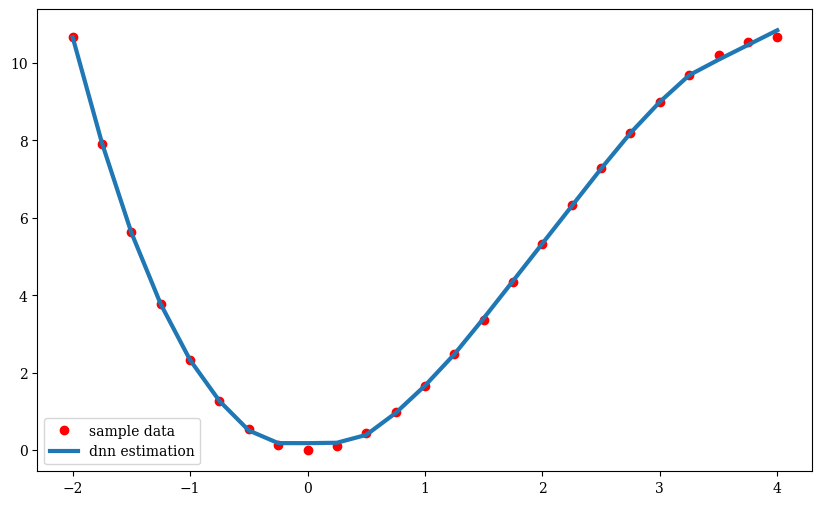

In [37]:
plt.figure(figsize=(10,6))
plt.plot(x, y, 'ro', label='sample data')
plt.plot(x, y_, lw=3.0, label='dnn estimation')
plt.legend()

The neural network approach relies on _incremental learning_

## Keras

_Keras:_ deep learning package

The model is fitted, _or trained_, for 100 epochs. The procedure is repeated for five rounds. After every round the approximation by the neural network is updated and plotted.

In [ ]:
import tensorflow as tf
tf.random.set_seed(100)

In [ ]:
from keras.layers import Dense
from keras.models import Sequential

In [ ]:
#1 Instantiates the Sequential model object
model = Sequential()
#2 Adds a densely connected hidden layer with rectified linear unit (ReLU) activations
model.add(Dense(256, activation='relu', input_dim=1))
#3 Adds the output layer with linear activation
model.add(Dense(1, activation='linear'))
#4 Complies the model for usage
model.compile(loss='mse', optimizer='rmsprop')

In [ ]:
((y - y_) ** 2).mean()

# Chapter 3. Normative Finance